# Khai báo thư viện


In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


# Load dữ liệu


In [2]:
train_data = pd.read_csv("/kaggle/input/titanic/train.csv")
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
test_data = pd.read_csv("/kaggle/input/titanic/test.csv")
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


# I. Xử lý các missing value


## 1. Kiểm tra missing value trong tập train


In [4]:
train_data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## 2. Bảng tương quan giữa các thuộc tính số (number)


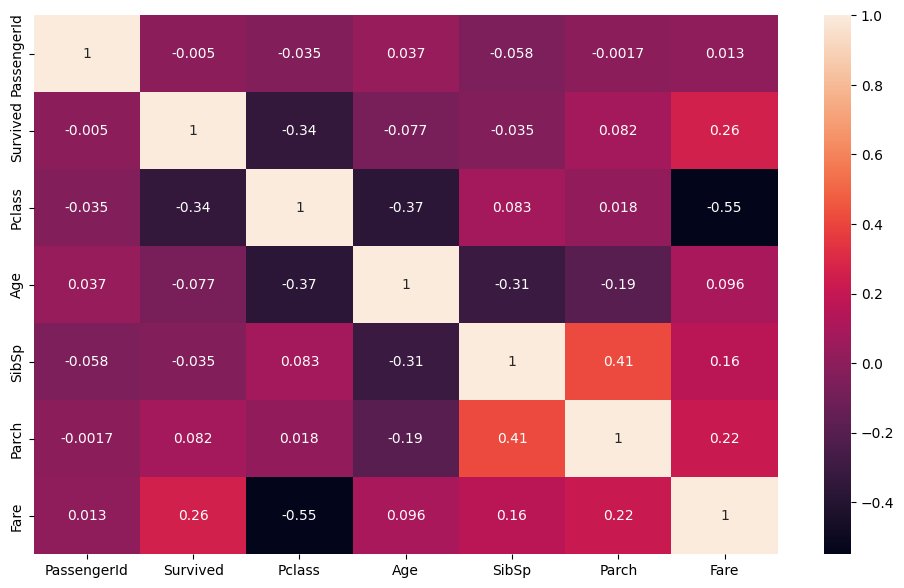

In [5]:
plt.figure(figsize=(12,7))
sns.heatmap(train_data.select_dtypes(include = ['number']).corr(), annot=True,)
plt.show()

<h3>-> Nhận xét: thấy 'Age' tương quan cao với 'Pclass'


## 3. Xử lý missing value trên tập train


### 3.1. Thuộc tính 'Age'

<h3>Nhận xét thấy Age tương quan vừa với Pclass -> Ta sẽ dùng IterativeImputer hoặc KNN với Pclass và Age


In [6]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer
from sklearn.linear_model import BayesianRidge

# --- BƯỚC 1: LỌC CÁC CỘT CẦN DÙNG ĐỂ IMUPUTE ---
# Ta chỉ cần 'Age' (cột có thiếu) và 'Pclass' (cột để dự đoán)
# Pclass cần được chuyển thành kiểu số nguyên nếu chưa phải
X_impute = train_data[['Age', 'Pclass']].copy()

# --- BƯỚC 2: KHỞI TẠO VÀ CẤU HÌNH KNNImputer ---
# Sử dụng BayesianRidge làm estimator thường tốt hơn LinearRegression mặc định
estimator = BayesianRidge()
imputer_age = KNNImputer(
    n_neighbors=5,  
    weights='uniform' 
)

# --- BƯỚC 3: FIT VÀ TRANSFORM DỮ LIỆU ---
# Fit: huấn luyện mô hình dự đoán trên dữ liệu có sẵn
# Transform: áp dụng mô hình để điền khuyết các giá trị NaN
X_imputed_array = imputer_age.fit_transform(X_impute)

# --- BƯỚC 4: CẬP NHẬT DATAFRAME GỐC ---
# Lấy cột Age đã được điền khuyết (cột đầu tiên của mảng kết quả)
train_data['Age_Imputed'] = X_imputed_array[:, 0]

# Chuyển đổi Age_Imputed sang số nguyên nếu bạn muốn tuổi là số nguyên
train_data['Age_Imputed'] = train_data['Age_Imputed'].round().astype(int)

# In kết quả
print("\nDataFrame sau khi điền khuyết:")
print(train_data[['Age', 'Pclass', 'Age_Imputed']].sample(5))


DataFrame sau khi điền khuyết:
      Age  Pclass  Age_Imputed
185   NaN       1           33
152  55.5       3           56
83   28.0       1           28
286  30.0       3           30
624  21.0       3           21


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


### 3.2. Thuộc tính: Embarked


<h3>Xử lý missing value Embarked dễ dàng vì chỉ có vài dòng bị mất


In [7]:
# Gán giá trị mode (giá trị xuất hiện nhiều nhất) cho các giá trị missing của cột "Embarked" 
most_common_embarked = train_data['Embarked'].mode()[0]
train_data['Embarked'] = train_data['Embarked'].fillna(most_common_embarked)

### 3.3. Kiểm tra hết missing value chưa


In [8]:
train_data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
Age_Imputed      0
dtype: int64

### 3.4. Danh sách các thuộc tính cần xóa


<h3> 
    - Age: vì đã xử lý và tạo thành cột Age_Imputed <br> <br>
    - Cabin: vì quá nhiều nhiều hàng chứ missing value -> khó xử lý <br><br>
    - Ticket: vì vừa mang giá trị số vừa mang giá chữ hoặc cả số cả chữ -> khó xử lý


In [10]:
train_data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
Age_Imputed      0
dtype: int64

## 4. Kiểm tra missing value bên tập test


In [11]:
test_data.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

---


## 5. Xử lý missing value trên tập test


### 5.1. Thuộc tính: Age


<h3> Thực hiện như bên tập train (Sử dụng KNN)


In [12]:
X_impute = test_data[['Age', 'Pclass']].copy()
X_imputed_array = imputer_age.transform(X_impute)
test_data['Age_Imputed'] = X_imputed_array[:, 0]
test_data['Age_Imputed'] = test_data['Age_Imputed'].round().astype(int)

### 5.2. Thuộc tính: Fare


<h3>Xử lý missing fare dễ dàng vì chỉ mất 1 hàng (Sử dụng median())


In [13]:
test_data['Fare'] = test_data['Fare'].fillna(test_data['Fare'].median())

### 5.3. Kiểm tra còn missing value không


In [14]:
test_data.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
Age_Imputed      0
dtype: int64

### 5.4. Danh sách các thuộc tính cần xóa


<h3>Xử lý như tập train <br><br>
    - Age: vì đã xử lý và tạo thành cột Age_Imputed <br> <br>
    - Cabin: vì quá nhiều nhiều hàng chứ missing value -> khó xử lý <br><br>
    - Ticket: vì vừa mang giá trị số vừa mang giá chữ hoặc cả số cả chữ -> khó xử lý


---


# II. Xử lý các Feature


## 1. Thuộc tính: Name


<h2>Xử lý name cho 2 tập bằng cách cắt ra từ đầu tiên sau dấu phẩy (Mr, Mrs, Dr,..)


In [15]:
# 1. Tạo Title từ Name (làm trước khi drop)
train_data['Title'] = train_data.Name.apply(lambda x: x.split(',')[1].split('.')[0].strip())
test_data['Title'] = test_data.Name.apply(lambda x: x.split(',')[1].split('.')[0].strip())

# 2. Lấy top 5 title phổ biến nhất
top_5_titles = train_data['Title'].value_counts().head(5).index.tolist()
print("Top 5 titles:", top_5_titles)

# 3. Gom tất cả title khác thành "Other"
train_data['Title'] = train_data['Title'].apply(lambda x: x if x in top_5_titles else 'Other')
test_data['Title'] = test_data['Title'].apply(lambda x: x if x in top_5_titles else 'Other')

# 4. Kiểm tra kết quả - CHỈ CÒN 6 CATEGORIES
print("\nAfter grouping - chỉ còn 6 categories:")
print(train_data['Title'].value_counts())
print("\nTest data Title counts:")
print(test_data['Title'].value_counts())

train_data['Title'] = train_data['Title'].map({'Mr':0, 'Miss':1, 'Mrs':2, 'Master':3, 'Dr':4, 'Other': 5}).astype('int')
test_data['Title'] = test_data['Title'].map({'Mr':0, 'Miss':1, 'Mrs':2, 'Master':3, 'Dr':4, 'Other': 5}).astype('int')

# # 5. Sau đó mới drop column Name



Top 5 titles: ['Mr', 'Miss', 'Mrs', 'Master', 'Dr']

After grouping - chỉ còn 6 categories:
Title
Mr        517
Miss      182
Mrs       125
Master     40
Other      20
Dr          7
Name: count, dtype: int64

Test data Title counts:
Title
Mr        240
Miss       78
Mrs        72
Master     21
Other       6
Dr          1
Name: count, dtype: int64


<h1>BoyOrFemale


In [16]:
def is_boy_row(row):
    # "boy" = male & (Age < 16 OR Title == 'Master')
    # age may be missing; Title helps
    return (row["Sex"] == "male") and ( (pd.notna(row["Age"]) and row["Age"] < 16) or (row.get("Title","") == "Master"))

train_data["Boy"] = train_data.apply(is_boy_row, axis=1)
train_data["WomanOrBoy"] = (train_data["Sex"] == "female") | (train_data["Boy"])
test_data["Boy"] = test_data.apply(is_boy_row, axis=1)
test_data["WomanOrBoy"] = (test_data["Sex"] == "female") | (test_data["Boy"])

## 2. Thuộc tính: Sex


<h2>Mã hóa cột Sex thành 0 - 1


In [17]:
# Map male - 0, fale - 1
train_data['Sex'] = train_data['Sex'].map({'male': 0, 'female': 1})
test_data['Sex'] = test_data['Sex'].map({'male': 0, 'female': 1})

## 3. Thuộc tính: Embarked


<h3>Mã hóa cột Embarked thành number


In [18]:
train_data['Embarked'].value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [19]:
pd.crosstab(index=train_data['Embarked'], columns=train_data['Survived'])

Survived,0,1
Embarked,,
C,75,93
Q,47,30
S,427,219


In [20]:
train_data['Embarked'] = train_data['Embarked'].map({'C': 1, 'Q': 2, 'S': 3})
test_data['Embarked'] = test_data['Embarked'].map({'C': 1, 'Q': 2, 'S': 3})

## 4. Tạo thêm thuộc tính: FamilySize = SibSp + Parch + 1 -> Số lượng thành viên trong gia đình


In [21]:
train_data['FamilySize'] = train_data['SibSp'] + train_data['Parch'] + 1
test_data['FamilySize'] = test_data['SibSp'] + test_data['Parch'] + 1
# train_data["FarePerPerson"] = (train_data["Fare"] / train_data["FamilySize"])
# test_data["FarePerPerson"] = (test_data["Fare"] / test_data["FamilySize"])

## 5. Thuộc tính: Fare


<h2>Histogram phân bố giá vé và tỷ lệ sống sót


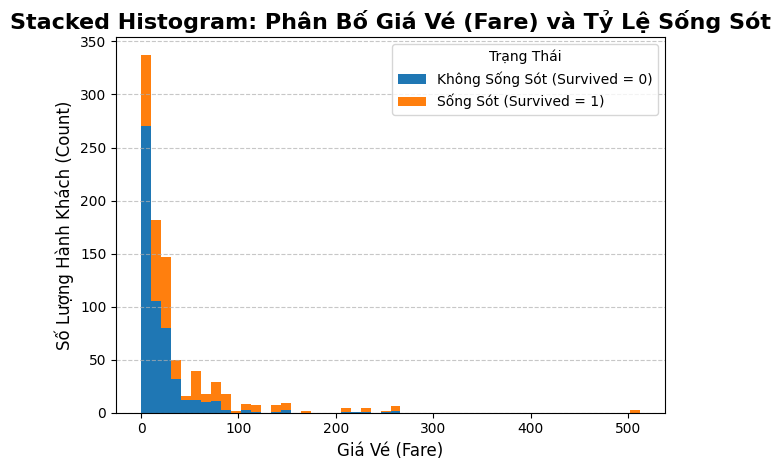

In [22]:
pd.crosstab(index=train_data['Fare'], columns = train_data['Survived'])
x_data1 = train_data[train_data['Survived'] == 0]['Fare']
x_data2 = train_data[train_data['Survived'] == 1]['Fare']
x_data = [x_data1, x_data2]
labels = ['Không Sống Sót (Survived = 0)', 'Sống Sót (Survived = 1)']
plt.hist(x_data, bins = 50, stacked=True, label=labels)
plt.title('Stacked Histogram: Phân Bố Giá Vé (Fare) và Tỷ Lệ Sống Sót', fontsize=16, fontweight='bold')
plt.xlabel('Giá Vé (Fare)', fontsize=12)
plt.ylabel('Số Lượng Hành Khách (Count)', fontsize=12)
plt.legend(loc='upper right', title="Trạng Thái")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [23]:
train_data['Fare'].value_counts()

Fare
8.0500     43
13.0000    42
7.8958     38
7.7500     34
26.0000    31
           ..
35.0000     1
28.5000     1
6.2375      1
14.0000     1
10.5167     1
Name: count, Length: 248, dtype: int64

<h2> Chia các giá trị trong Fare theo 4 khoảng -> Tạo thêm thuộc tính Fare_Cat


In [24]:
# Cắt các giá trị theo khoảng và gắn labels
train_data['Fare_Cat'] = pd.cut(train_data['Fare'], bins=[0,40,80,200,1000], labels=['so_cheap', 'cheap', 'Medium', 'Expensive'])
test_data['Fare_Cat'] = pd.cut(test_data['Fare'], bins=[0,40,80,200,1000], labels=['so_cheap', 'cheap', 'Medium', 'Expensive']) 


# train_data['Fare_Cat'] = pd.qcut(train_data["Fare"], 4, duplicates="drop")
# train_data['Fare_Cat'] = train_data["Fare_Cat"].cat.codes
# test_data['Fare_Cat'] = pd.qcut(test_data["Fare"], 4, duplicates="drop")
# test_data['Fare_Cat'] = test_data["Fare_Cat"].cat.codes

## 6. Thuộc tính: Age


<h2>Histogram phân bố Age và tỷ lệ sống sót


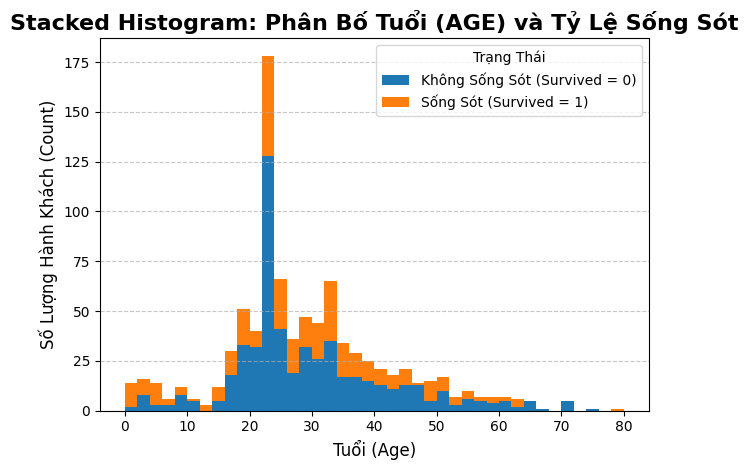

In [25]:
pd.crosstab(index=train_data['Age_Imputed'], columns = train_data['Survived'])
x_data1 = train_data[train_data['Survived'] == 0]['Age_Imputed']
x_data2 = train_data[train_data['Survived'] == 1]['Age_Imputed']
x_data = [x_data1, x_data2]
labels = ['Không Sống Sót (Survived = 0)', 'Sống Sót (Survived = 1)']
plt.hist(x_data, bins = 40, stacked=True, label=labels)
plt.title('Stacked Histogram: Phân Bố Tuổi (AGE) và Tỷ Lệ Sống Sót', fontsize=16, fontweight='bold')
plt.xlabel('Tuổi (Age)', fontsize=12)
plt.ylabel('Số Lượng Hành Khách (Count)', fontsize=12)
plt.legend(loc='upper right', title="Trạng Thái")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<h2> Chia các giá trị trong Age theo 6 khoảng -> Tạo thêm thuộc tính Age_Cat


0-12
12-22
22-34
34-46
46-64
64-100


In [26]:
# Cắt các giá trị theo khoảng và gắn labels
train_data['Age_Cat'] = pd.cut(train_data['Age_Imputed'], bins=[0,12,22,34,46,64,100], labels=['babi', 'so_young', 'young', 'teenager', 'adult', 'old'])
test_data['Age_Cat'] = pd.cut(test_data['Age_Imputed'], bins=[0,12,22,34,46,64,100], labels=['babi', 'so_young', 'young', 'teenager', 'adult', 'old']) 

# train_data['Age_Cat'] = train_data['Age_Cat'].map({'babi': 1, 'so_young': 2, 'young': 3, 'teenager': 4, 'adult': 5, 'old': 6}).astype('int')
# test_data['Age_Cat'] = test_data['Age_Cat'].map({'babi': 1, 'so_young': 2, 'young': 3, 'teenager': 4, 'adult': 5, 'old': 6}).astype('int') 


# train_data['Age_Cat'] = pd.qcut(train_data["Age_Imputed"], 8, duplicates="drop")
# train_data['Age_Cat'] = train_data["Age_Cat"].cat.codes
# test_data['Age_Cat'] = pd.qcut(test_data["Age_Imputed"], 8, duplicates="drop")
# test_data['Age_Cat'] = test_data["Age_Cat"].cat.codes

## 7. Tạo thêm thuộc tính Family_Survival


In [27]:
train_data["Last_Name"] = train_data["Name"].str.split(",").str[0]
test_data["Last_Name"] = test_data["Name"].str.split(",").str[0]

In [28]:
DEFAULT_SURV = 0.5
fam_rules = {}
tmp = train_data.copy()
tmp["Last_Name"] = tmp["Name"].str.split(",").str[0]
tmp["Fare"] = tmp["Fare"].fillna(tmp["Fare"].median())
for (lname, fare), grp in tmp.groupby(["Last_Name", "Fare"], dropna=False):
    if len(grp) <= 1:
        continue
    smax = grp["Survived"].max()
    smin = grp["Survived"].min()
    if smax == 1:
        fam_rules[("LF", lname, fare)] = 1.0
    elif smin == 0:
        fam_rules[("LF", lname, fare)] = 0.0

In [29]:
# Quy tắc theo Ticket trong TRAIN
for ticket, grp in tmp.groupby("Ticket", dropna=False):
    if len(grp) <= 1:
        continue
    smax = grp["Survived"].max()
    smin = grp["Survived"].min()
    if smax == 1:
        fam_rules[("T", ticket)] = 1.0
    elif smin == 0:
        fam_rules[("T", ticket)] = 0.0

In [30]:
def infer_family_survival(row):
    # Ưu tiên quy tắc theo Last_Name + Fare
    key1 = ("LF", row["Last_Name"], row["Fare"])
    if key1 in fam_rules:
        return fam_rules[key1]
    # Sau đó đến Ticket
    key2 = ("T", row["Ticket"])
    if key2 in fam_rules:
        return fam_rules[key2]
    return DEFAULT_SURV

train_data["Family_Survival"] = train_data.apply(infer_family_survival, axis=1)
test_data["Family_Survival"] = test_data.apply(infer_family_survival, axis=1)

In [31]:
train_data['Family_Survival'].value_counts()

Family_Survival
0.5    516
1.0    236
0.0    139
Name: count, dtype: int64

## 8. Dummies để tăng hiệu suất train


<h2> Các thuộc tính Categories cần dummies: <br> <br>
    - Title <br> <br>
    - Fare_Cat <br> <br>
    - Age_Cat


In [37]:
dummies_col = ['Title', 'Fare_Cat', 'Age_Cat']
for col in dummies_col:
    train_data = pd.get_dummies(train_data, columns=[col], drop_first=True)
    test_data = pd.get_dummies(test_data, columns=[col], drop_first=True)

## 9. Tạo thêm thuộc tính: IsAlone (Người đó có đi một mình hay không)


In [38]:
train_data['IsAlone'] = (train_data['FamilySize'] == 1).astype(int)
test_data['IsAlone'] = (test_data['FamilySize'] == 1).astype(int)

## 10. Xóa các cột không cần thiết cho việc train model


In [39]:
train_data.isna().sum()

PassengerId             0
Survived                0
Pclass                  0
Name                    0
Sex                     0
Age                   177
SibSp                   0
Parch                   0
Ticket                  0
Fare                    0
Cabin                 687
Embarked                0
Age_Imputed             0
Boy                     0
WomanOrBoy              0
FamilySize              0
Last_Name               0
Family_Survival         0
Title_1                 0
Title_2                 0
Title_3                 0
Title_4                 0
Title_5                 0
Fare_Cat_cheap          0
Fare_Cat_Medium         0
Fare_Cat_Expensive      0
Age_Cat_so_young        0
Age_Cat_young           0
Age_Cat_teenager        0
Age_Cat_adult           0
Age_Cat_old             0
IsAlone                 0
dtype: int64

<h2>Drop data


In [40]:
drop_cols = ['PassengerId', 'Cabin', 'Ticket', 'Name', 'Age', 'Fare', 'Last_Name', 'Age_Imputed']
for col in drop_cols:
    train_data.drop(columns=[col], inplace=True)
    test_data.drop(columns=[col], inplace=True)

<h2>Kiểm tra lại còn missing value không


In [41]:
train_data.isna().sum()

Survived              0
Pclass                0
Sex                   0
SibSp                 0
Parch                 0
Embarked              0
Boy                   0
WomanOrBoy            0
FamilySize            0
Family_Survival       0
Title_1               0
Title_2               0
Title_3               0
Title_4               0
Title_5               0
Fare_Cat_cheap        0
Fare_Cat_Medium       0
Fare_Cat_Expensive    0
Age_Cat_so_young      0
Age_Cat_young         0
Age_Cat_teenager      0
Age_Cat_adult         0
Age_Cat_old           0
IsAlone               0
dtype: int64

---


# III. Huấn luyện mô hình


## 1. Scale data


In [42]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scale_cols = ['Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked', 'FamilySize','Family_Survival']
for col in test_data.columns:
    train_data[col] = scaler.fit_transform(train_data[[col]])
    test_data[col] = scaler.transform(test_data[[col]])

## 2. Chia tập train thành hai tập khác nhau


<h2>- Một tập để huấn luyện <br><br>
    - Một tập để validation


In [43]:
from sklearn.model_selection import train_test_split

X = train_data.drop('Survived', axis=1)
y = train_data['Survived']
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [44]:
train_data.select_dtypes(include=['object']).columns

Index([], dtype='object')

## 3. Huấn luyện với 3 mô hình


<h2> 
    - LogisticRegression <br><br>
    - RandomForestClassifier <br><br>
    - XGBClassifier


In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=200),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:,1]

    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_prob)

    print(f"{name} Results:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    print(f"  ROC AUC:  {roc_auc:.4f}")
    print("-" * 30)

Logistic Regression Results:
  Accuracy: 0.8380
  F1 Score: 0.7914
  ROC AUC:  0.9072
------------------------------
Random Forest Results:
  Accuracy: 0.7989
  F1 Score: 0.7313
  ROC AUC:  0.8764
------------------------------
XGBoost Results:
  Accuracy: 0.8045
  F1 Score: 0.7482
  ROC AUC:  0.8480
------------------------------


## 4. Dựa vào kết quả huấn luyện để chọn mô hình đạt hiệu suất cao


In [46]:
best_model = LogisticRegression(random_state=42, max_iter=1000)
# best_model = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=200)
# best_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)
best_model.fit(X_train, y_train)

y_val_pred = best_model.predict(X_val)

print("Actual values (first 5):")
print(y_val.head())

print("\nPredicted values (first 5):")
print(pd.Series(y_val_pred).head())

Actual values (first 5):
565    0
160    0
553    1
860    0
241    1
Name: Survived, dtype: int64

Predicted values (first 5):
0    0
1    0
2    0
3    0
4    1
dtype: int64


## 5. Tạo file submission.csv vào nộp lên kaggle


In [47]:
# Orijinal test csv'sini tekrar yükle (PassengerId için)
test_data_orig = pd.read_csv("/kaggle/input/titanic/test.csv")

# 1. Lấy danh sách tên cột từ tập huấn luyện (X_train)
# Đây là danh sách các cột mà mô hình của bạn đã được fit (học).
# LƯU Ý: Phải sử dụng X_train (hoặc biến chứa các features đã dùng để fit mô hình)
feature_cols_at_fit = X_train.columns

# 2. Đồng bộ hóa tập test_data
# Đảm bảo test_data có số lượng cột, tên cột và thứ tự cột giống hệt X_train.
# Các cột thiếu (ví dụ: 'Cabin_Imputed_7.0') sẽ được thêm vào với giá trị 0.
test_data_aligned = test_data.reindex(columns=feature_cols_at_fit, fill_value=0)

# best_model ile test verisi üzerinde tahmin yap
test_preds = best_model.predict(test_data_aligned)

# Submission dataframe'i oluştur
submission = pd.DataFrame({
    "PassengerId": test_data_orig["PassengerId"],
    "Survived": test_preds
})

# CSV olarak kaydet (kaggle ortamında)
submission.to_csv("submission.csv", index=False)

print("Submission file 'submission.csv' created.")

Submission file 'submission.csv' created.
